# Importações

In [119]:
# Bibliotecas de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import shap
import joblib

In [120]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/CreditRiskCleanDataset.csv")

df

,Age,Credit amount,Duration,Risk,Job_highly skilled,Job_skilled,Job_unskilled non-resident,Job_unskilled resident,Housing_free,Housing_own,...,Checking account_none,Checking account_rich,Purpose_business,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,67,7.064759,6,1,0,1,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
1,22,8.691483,48,0,0,1,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
2,49,7.648263,12,1,0,0,0,1,0,1,...,1,0,0,0,0,1,0,0,0,0
3,45,8.972464,42,1,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0
4,53,8.491055,24,0,0,1,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,31,7.459915,12,1,0,0,0,1,0,1,...,1,0,0,0,0,0,1,0,0,0
996,40,8.257904,30,1,1,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
997,38,6.690842,12,1,0,1,0,0,0,1,...,1,0,0,0,0,0,0,1,0,0
998,23,7.520776,45,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0


# Definição das features e do target

In [121]:
# Colocando a variável dependente na última posição do dataset
features = [col for col in df.columns if col != 'Risk']
features_target = features + ['Risk']
df = df[features_target]


# Definindo as nossas features (X) e o target (y)

X = df.iloc[:, :-1] # todas as colunas menos a última
y = df.iloc[:, -1] # última coluna

df.head()

,Age,Credit amount,Duration,Job_highly skilled,Job_skilled,Job_unskilled non-resident,Job_unskilled resident,Housing_free,Housing_own,Housing_rent,...,Checking account_rich,Purpose_business,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others,Risk
0,67,7.064759,6,0,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
1,22,8.691483,48,0,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0
2,49,7.648263,12,0,0,0,1,0,1,0,...,0,0,0,0,1,0,0,0,0,1
3,45,8.972464,42,0,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,1
4,53,8.491055,24,0,1,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0


# Analisando melhor nossas features

In [122]:
# Checar os dados
df.head()
df.describe()
df.info()
df.corr()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          1000 non-null   int64  
 1   Credit amount                1000 non-null   float64
 2   Duration                     1000 non-null   int64  
 3   Job_highly skilled           1000 non-null   int64  
 4   Job_skilled                  1000 non-null   int64  
 5   Job_unskilled non-resident   1000 non-null   int64  
 6   Job_unskilled resident       1000 non-null   int64  
 7   Housing_free                 1000 non-null   int64  
 8   Housing_own                  1000 non-null   int64  
 9   Housing_rent                 1000 non-null   int64  
 10  Saving accounts_little       1000 non-null   int64  
 11  Saving accounts_moderate     1000 non-null   int64  
 12  Saving accounts_none         1000 non-null   int64  
 13  Saving accounts_quite rich   1

,Age,Credit amount,Duration,Job_highly skilled,Job_skilled,Job_unskilled non-resident,Job_unskilled resident,Housing_free,Housing_own,Housing_rent,...,Checking account_rich,Purpose_business,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others,Risk
Age,1.000000,0.011702,-0.036136,0.127605,-0.148283,0.059954,0.043712,0.253058,0.006553,-0.212620,...,0.037504,-0.001772,0.099919,-0.012562,0.060390,-0.127657,-0.046401,0.039567,0.042365,0.091127
Credit amount,0.011702,1.000000,0.640850,0.291044,-0.031736,-0.052032,-0.200988,0.182935,-0.118644,-0.008111,...,-0.095567,0.119261,0.110218,-0.092825,-0.077808,0.036352,-0.178825,-0.039955,0.121258,-0.109588
Duration,-0.036136,0.640850,1.000000,0.147515,0.055010,-0.044043,-0.181203,0.189117,-0.075169,-0.064417,...,-0.076455,0.164113,-0.005320,-0.037212,-0.025450,-0.062804,-0.044319,-0.022549,0.104516,-0.214927
Job_highly skilled,0.127605,0.291044,0.147515,1.000000,-0.543852,-0.062511,-0.208392,0.154388,-0.071741,-0.040344,...,-0.015346,0.006128,0.113935,-0.045933,-0.008749,-0.042335,-0.096839,-0.062511,0.186835,-0.040559
Job_skilled,-0.148283,-0.031736,0.055010,-0.543852,1.000000,-0.195709,-0.652438,-0.033633,0.012866,0.012049,...,-0.022932,-0.007768,-0.097759,0.046414,-0.019075,0.064393,0.085802,-0.012144,-0.124785,0.013559
Job_unskilled non-resident,0.059954,-0.052032,-0.044043,-0.062511,-0.195709,1.000000,-0.074991,0.035671,-0.040480,0.018886,...,0.073347,-0.003087,0.066143,0.046082,-0.008622,-0.052801,-0.063164,0.070459,0.046082,-0.005951
Job_unskilled resident,0.043712,-0.200988,-0.181203,-0.208392,-0.652438,-0.074991,1.000000,-0.109543,0.063003,0.014347,...,0.014405,0.005068,-0.007405,-0.032144,0.033952,-0.020778,0.005568,0.044313,-0.032144,0.021822
Housing_free,0.253058,0.182935,0.189117,0.154388,-0.033633,0.035671,-0.109543,1.000000,-0.548445,-0.162474,...,0.015860,-0.059613,0.126806,-0.038348,0.117976,-0.071530,-0.109357,0.013706,0.080010,-0.081556
Housing_own,0.006553,-0.118644,-0.075169,-0.071741,0.012866,-0.040480,0.063003,-0.548445,1.000000,-0.735968,...,0.018934,0.051083,-0.099526,0.029317,-0.075684,-0.040496,0.134705,0.019803,-0.011288,0.134589
Housing_rent,-0.212620,-0.008111,-0.064417,-0.040344,0.012049,0.018886,0.014347,-0.162474,-0.735968,1.000000,...,-0.035183,-0.012013,0.014773,-0.003546,-0.006211,0.105700,-0.070414,-0.034465,-0.051460,-0.092785


In [123]:
# Visualizando as nossas features

print("=== FEATURES (X) ===")
print(f"Formato do dataset: {X.shape}")
print(f"Número de amostras: {X.shape[0]}")
print(f"Número de features: {X.shape[1]}")

=== FEATURES (X) ===
Formato do dataset: (1000, 27)
Número de amostras: 1000
Número de features: 27


# Dando uma olhada no target

In [124]:
# Visualizando o nosso target


# Transformando a flag binária da coluna 'TenYearCHD' em strings
nomeando_classes = {0: 'bad', 1: 'good'}
y_classes = y.map(nomeando_classes)


print(f"Classes do target: {y_classes.unique()}")
print(f"Distribuição das classes:")
print(f"  No (0): {sum(y == 0)} ({sum(y == 0)/len(y)*100:.1f}%)")
print(f"  Yes (1): {sum(y == 1)} ({sum(y == 1)/len(y)*100:.1f}%)")

Classes do target: <StringArray>
['good', 'bad']
Length: 2, dtype: str
Distribuição das classes:
  No (0): 300 (30.0%)
  Yes (1): 700 (70.0%)


# Dando uma última olhada no dataframe

In [125]:
linhas_com_nulos = df[df.isnull().any(axis=1)]

print(linhas_com_nulos)

Empty DataFrame
Columns: [Age, Credit amount, Duration, Job_highly skilled, Job_skilled, Job_unskilled non-resident, Job_unskilled resident, Housing_free, Housing_own, Housing_rent, Saving accounts_little, Saving accounts_moderate, Saving accounts_none, Saving accounts_quite rich, Saving accounts_rich, Checking account_little, Checking account_moderate, Checking account_none, Checking account_rich, Purpose_business, Purpose_car, Purpose_domestic appliances, Purpose_education, Purpose_furniture/equipment, Purpose_radio/TV, Purpose_repairs, Purpose_vacation/others, Risk]
Index: []

[0 rows x 28 columns]


In [126]:
# Informações sobre o nosso dataset
print("=== VISÃO GERAL DO DATASET ===")
print(f"Formato do dataset: {X.shape}")
print(f"Formato do target: {y.shape}")


print("\n=== PRIMEIRAS 5 LINHAS ===")
print(X.head())


print("\n=== RESUMO ESTATÍSTICO ===")
print(X.describe())


print("\n=== TIPOS DE DADOS E VALORES AUSENTES ===")
print(X.info())
print(f"\nValores ausentes nas features: {X.isnull().sum().sum()}")
print(f"Valores ausentes no target: {pd.isnull(y).sum()}")

=== VISÃO GERAL DO DATASET ===
Formato do dataset: (1000, 27)
Formato do target: (1000,)

=== PRIMEIRAS 5 LINHAS ===
   Age  Credit amount  Duration  Job_highly skilled  Job_skilled  \
0   67       7.064759         6                   0            1   
1   22       8.691483        48                   0            1   
2   49       7.648263        12                   0            0   
3   45       8.972464        42                   0            1   
4   53       8.491055        24                   0            1   

   Job_unskilled non-resident  Job_unskilled resident  Housing_free  \
0                           0                       0             0   
1                           0                       0             0   
2                           0                       1             0   
3                           0                       0             1   
4                           0                       0             1   

   Housing_own  Housing_rent  ...  Checking acc

# Machine Learning

## Separando os conjuntos de treino e teste

In [127]:
# Separar treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Criando o Scaler

In [128]:
# Fazer o Feature Scaling (se necessário)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features standardized")

Features standardized


## Criando o modelo de regressão logística

In [129]:
# Criar o modelo (usando uma classe do sklearn)
# Nesse exemplo é Regressão Logística, mas pode ser a Linear que vimos
# Ou qualquer outro modelo que você quiser (e.g. SVM, Random Forest, etc)
model = LogisticRegression(class_weight='balanced', random_state=42)

## Treinando o modelo

In [130]:
# Treinar o modelo (sim, o fit faz todo aquele processo que vimos em sala)
# Ele vai calcular o erro, o gradiente, e atualizar os pesos
# Isso vai criar o modelo, e ele vai ser capaz de fazer previsões (criando a função de inferência)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

## Avaliações do desempenho

In [131]:
# Fazer o teste e as previsões necessárias
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)

In [132]:
# Fazer a avaliação do modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6800
              precision    recall  f1-score   support

           0       0.48      0.78      0.59        60
           1       0.87      0.64      0.74       140

    accuracy                           0.68       200
   macro avg       0.68      0.71      0.67       200
weighted avg       0.75      0.68      0.69       200

[[47 13]
 [51 89]]


In [133]:
print(f"\n=== CONCLUSÃO DA ANÁLISE ===")
if accuracy > 0.95:
    print("🎯 EXCELENTE: Modelo demonstra performance excepcional!")
elif accuracy > 0.90:
    print("✅ MUITO BOM: Modelo apresenta alta acurácia!")
elif accuracy > 0.85:
    print("👍 BOM: Modelo apresenta boa performance!")
else:
    print("⚠️  MELHORIAS NECESSÁRIAS: Modelo precisa de ajustes!")


=== CONCLUSÃO DA ANÁLISE ===
⚠️  MELHORIAS NECESSÁRIAS: Modelo precisa de ajustes!


## SHAP

In [134]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Usa os _df aqui, não os originais!
explainer = shap.LinearExplainer(model, X_train_scaled_df)
shap_values = explainer(X_test_scaled_df)

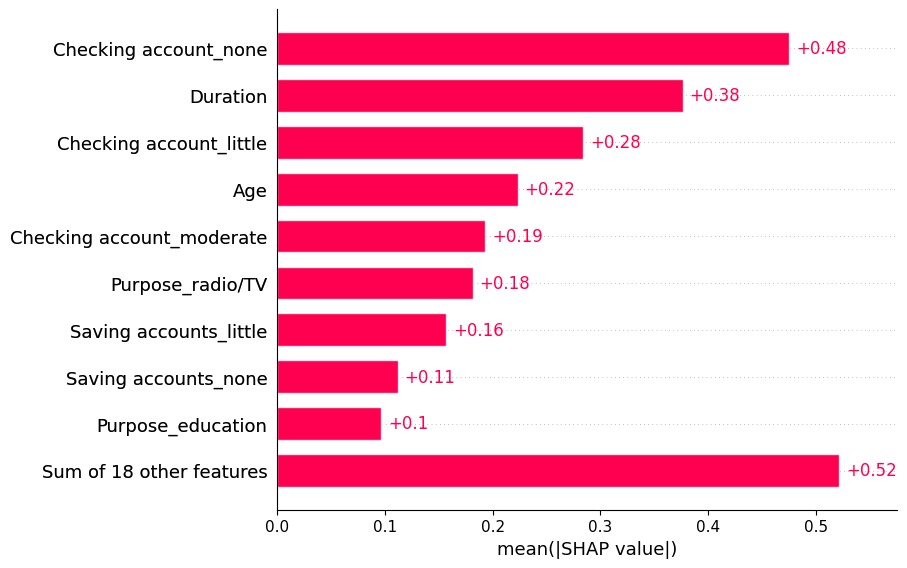

In [135]:
shap.plots.bar(shap_values)

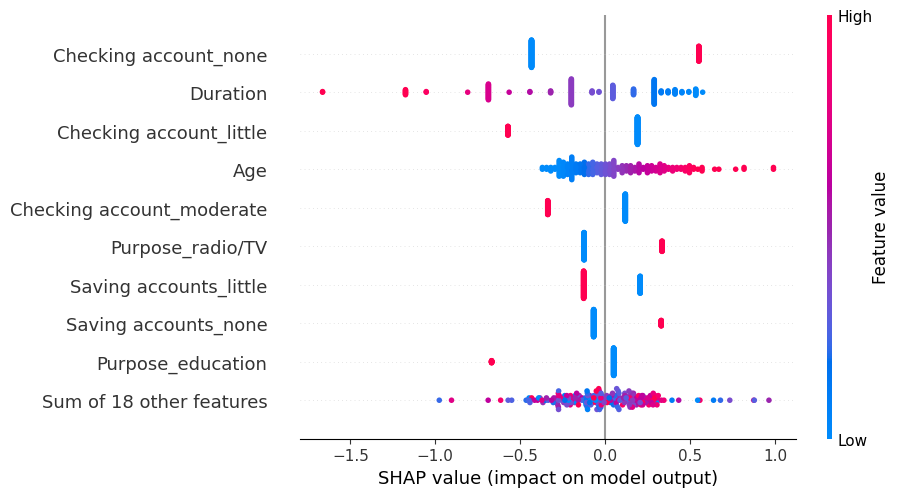

In [136]:
shap.plots.beeswarm(shap_values)

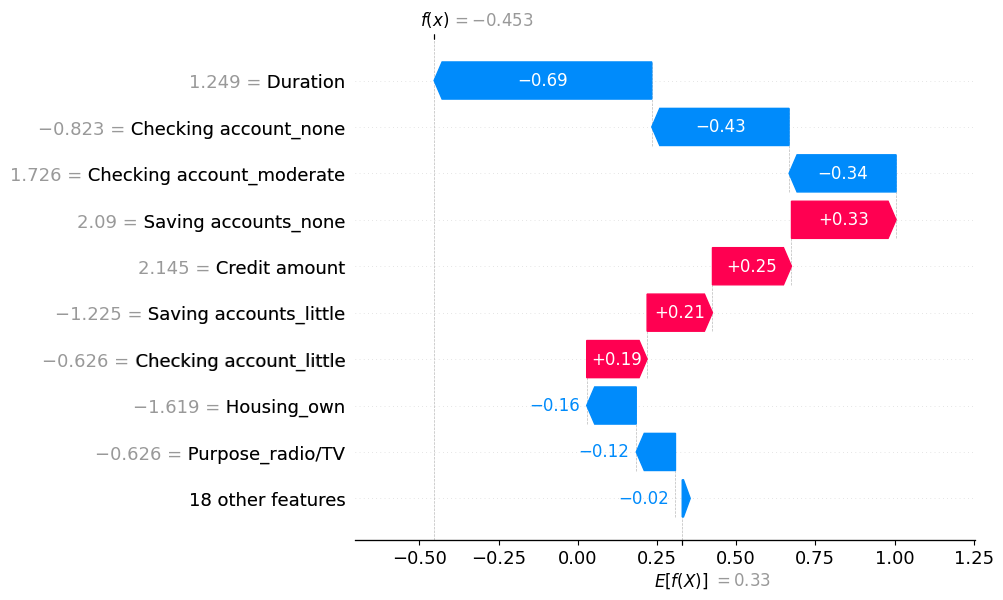

In [137]:
# Pega um mau pagador real pra explicar
indice_mau_pagador = (y_test == 0).values.nonzero()[0][0]
shap.plots.waterfall(shap_values[indice_mau_pagador])

In [139]:
joblib.dump(model, '../models/credit_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

['../models/scaler.pkl']